# 乳腺癌肿瘤分类 —— 多模型对比
**合肥工业大学宣城校区 · 机器学习实战**

数据集：Breast Cancer Wisconsin (Diagnostic)  
目标：对恶性肿瘤（M）和良性肿瘤（B）进行二分类，尝试 6 种分类方法并比较结果。

## 1. 环境准备

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


## 2. 数据加载与初步查看

In [2]:
df = pd.read_csv('breast cancer.csv')
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print('数据形状：', df.shape)
df.head()

数据形状： (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [4]:
pd.DataFrame({
    '类别': ['良性 (B=0)', '恶性 (M=1)'],
    '数量': df['diagnosis'].value_counts().values,
    '占比': (df['diagnosis'].value_counts(normalize=True).values * 100).round(2)
}).assign(占比=lambda x: x['占比'].astype(str) + '%')

,类别,数量,占比
0,良性 (B=0),357,62.74%
1,恶性 (M=1),212,37.26%


## 3. 数据可视化

### 3.1 类别分布

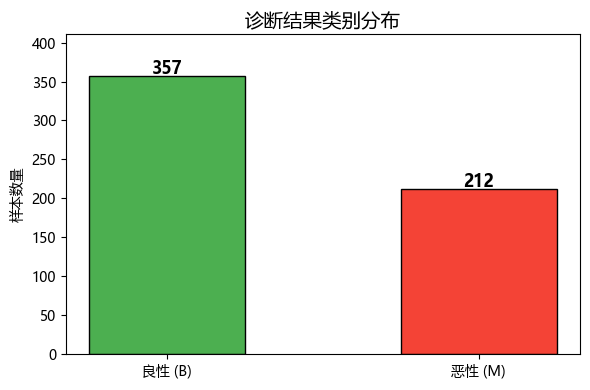

In [5]:
counts = df['diagnosis'].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(['良性 (B)', '恶性 (M)'], counts.values,
               color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             str(val), ha='center', fontsize=12, fontweight='bold')
plt.title('诊断结果类别分布', fontsize=14)
plt.ylabel('样本数量')
plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

### 3.2 关键特征箱线图（良性 vs 恶性）

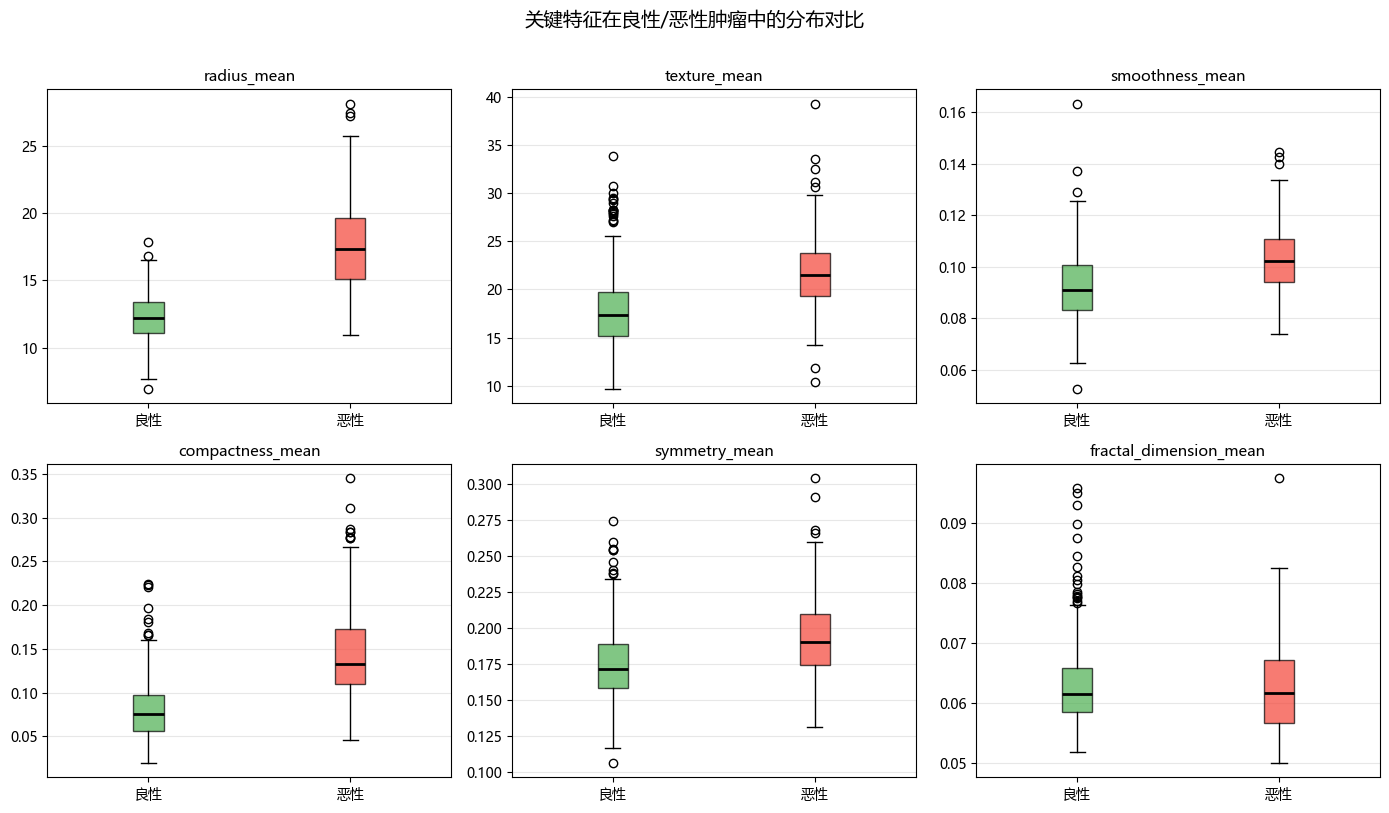

In [6]:
key_features = ['radius_mean', 'texture_mean', 'smoothness_mean',
                'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = ['#4CAF50', '#F44336']

for i, feat in enumerate(key_features):
    data_b = df[df['diagnosis'] == 0][feat]
    data_m = df[df['diagnosis'] == 1][feat]
    bp = axes[i].boxplot([data_b, data_m], patch_artist=True,
                         labels=['良性', '恶性'],
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=11)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('关键特征在良性/恶性肿瘤中的分布对比', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 相关系数热力图

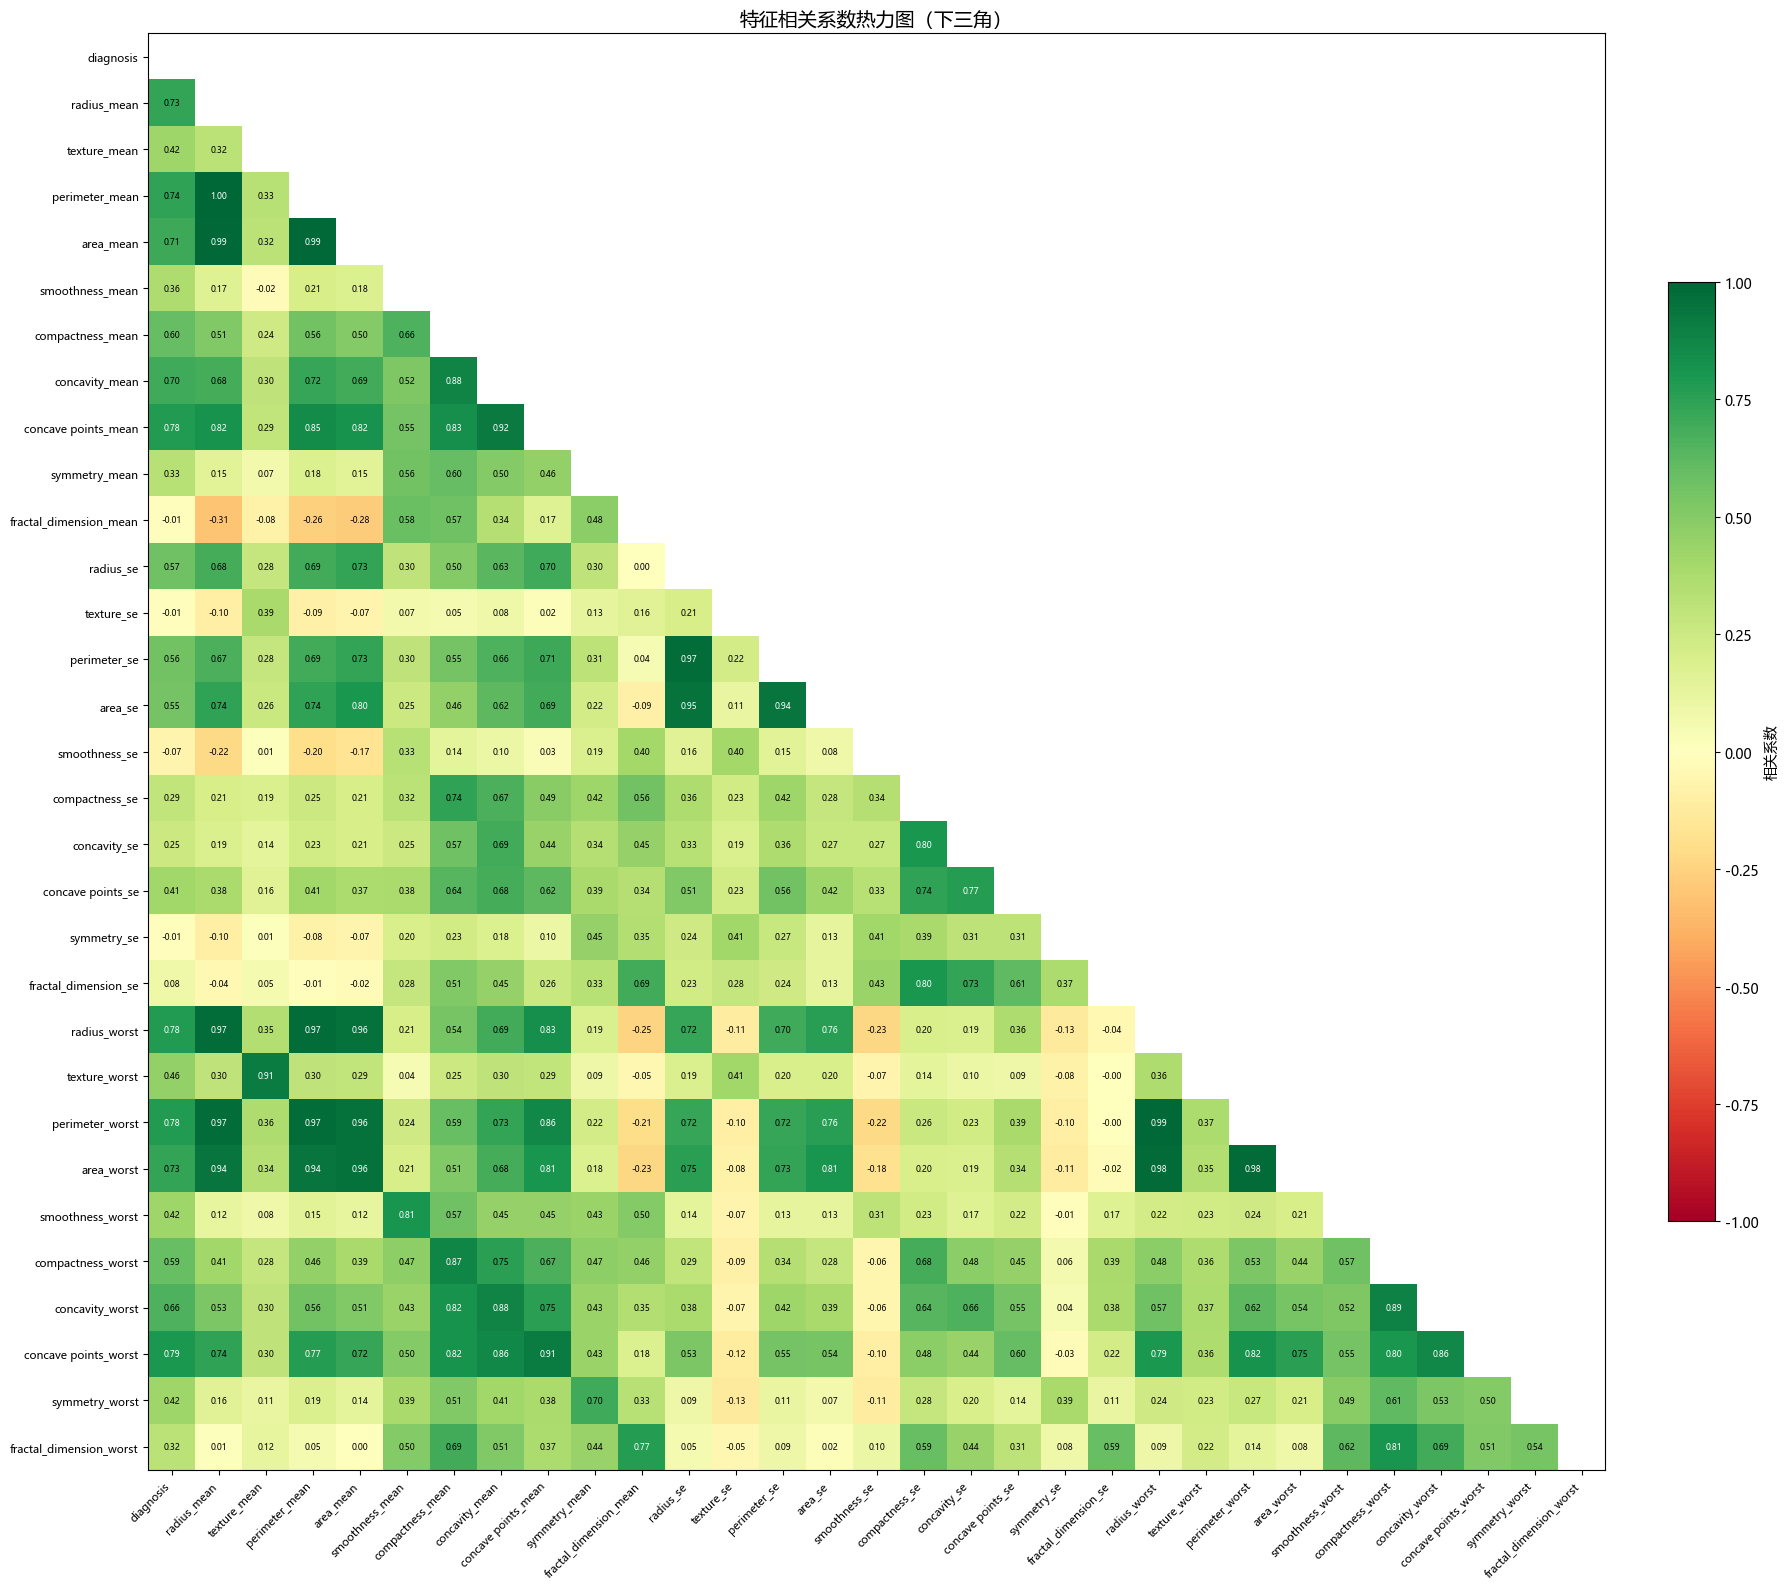

In [7]:
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 16))
im = plt.imshow(np.where(mask, np.nan, corr.values),
                cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, fraction=0.03, pad=0.04, label='相关系数')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)
plt.title('特征相关系数热力图（下三角）', fontsize=14)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if not mask[i, j]:
            val = corr.values[i, j]
            c = 'white' if abs(val) > 0.75 else 'black'
            plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=c)
plt.tight_layout()
plt.show()

## 4. 特征工程与数据准备

In [8]:
drop_cols = [
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst',
    'perimeter_mean', 'perimeter_se', 'area_mean', 'area_se',
    'concavity_mean', 'concavity_se', 'concave points_mean', 'concave points_se'
]
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

print('去除多重共线性后保留的特征：')
pd.DataFrame({'特征名': df_clean.columns.tolist()})

去除多重共线性后保留的特征：


,特征名
0,diagnosis
1,radius_mean
2,texture_mean
3,smoothness_mean
4,compactness_mean
5,symmetry_mean
6,fractal_dimension_mean
7,radius_se
8,texture_se
9,smoothness_se


In [9]:
X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'训练集：{X_train_sc.shape}，测试集：{X_test_sc.shape}')

训练集：(398, 12)，测试集：(171, 12)


## 5. 六种分类模型训练与评估

### 5.1 定义模型

In [10]:
models = {
    '逻辑回归 (LR)': LogisticRegression(max_iter=1000, random_state=42),
    '决策树 (DT)': DecisionTreeClassifier(random_state=42),
    '随机森林 (RF)': RandomForestClassifier(n_estimators=100, random_state=42),
    '梯度提升 (GBDT)': GradientBoostingClassifier(n_estimators=100, random_state=42),
    '支持向量机 (SVM)': SVC(probability=True, random_state=42),
    'K近邻 (KNN)': KNeighborsClassifier(n_neighbors=5)
}
print('模型列表：')
pd.DataFrame({'模型名称': list(models.keys())})

模型列表：


,模型名称
0,逻辑回归 (LR)
1,决策树 (DT)
2,随机森林 (RF)
3,梯度提升 (GBDT)
4,支持向量机 (SVM)
5,K近邻 (KNN)


### 5.2 训练并汇总评估指标

In [11]:
results = []
trained_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='accuracy')

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        '模型': name,
        '测试准确率': round(acc, 4),
        '精确率': round(precision, 4),
        '召回率': round(recall, 4),
        'F1分数': round(f1, 4),
        'AUC': round(auc_score, 4),
        '5折CV均值': round(cv_scores.mean(), 4),
        '5折CV标准差': round(cv_scores.std(), 4)
    })
    trained_models[name] = (model, y_pred, y_prob)

results_df = pd.DataFrame(results).set_index('模型')
results_df

,测试准确率,精确率,召回率,F1分数,AUC,5折CV均值,5折CV标准差
模型,,,,,,,
逻辑回归 (LR),0.9240,0.9180,0.8750,0.8960,0.9861,0.9372,0.0237
决策树 (DT),0.8772,0.8308,0.8438,0.8372,0.8705,0.8520,0.0393
随机森林 (RF),0.9298,0.9643,0.8438,0.9000,0.9840,0.9273,0.0287
梯度提升 (GBDT),0.9240,0.9180,0.8750,0.8960,0.9810,0.9097,0.0345
支持向量机 (SVM),0.9357,0.9492,0.8750,0.9106,0.9801,0.9422,0.0127
K近邻 (KNN),0.9298,0.9483,0.8594,0.9016,0.9776,0.9297,0.0168


### 5.3 各模型混淆矩阵

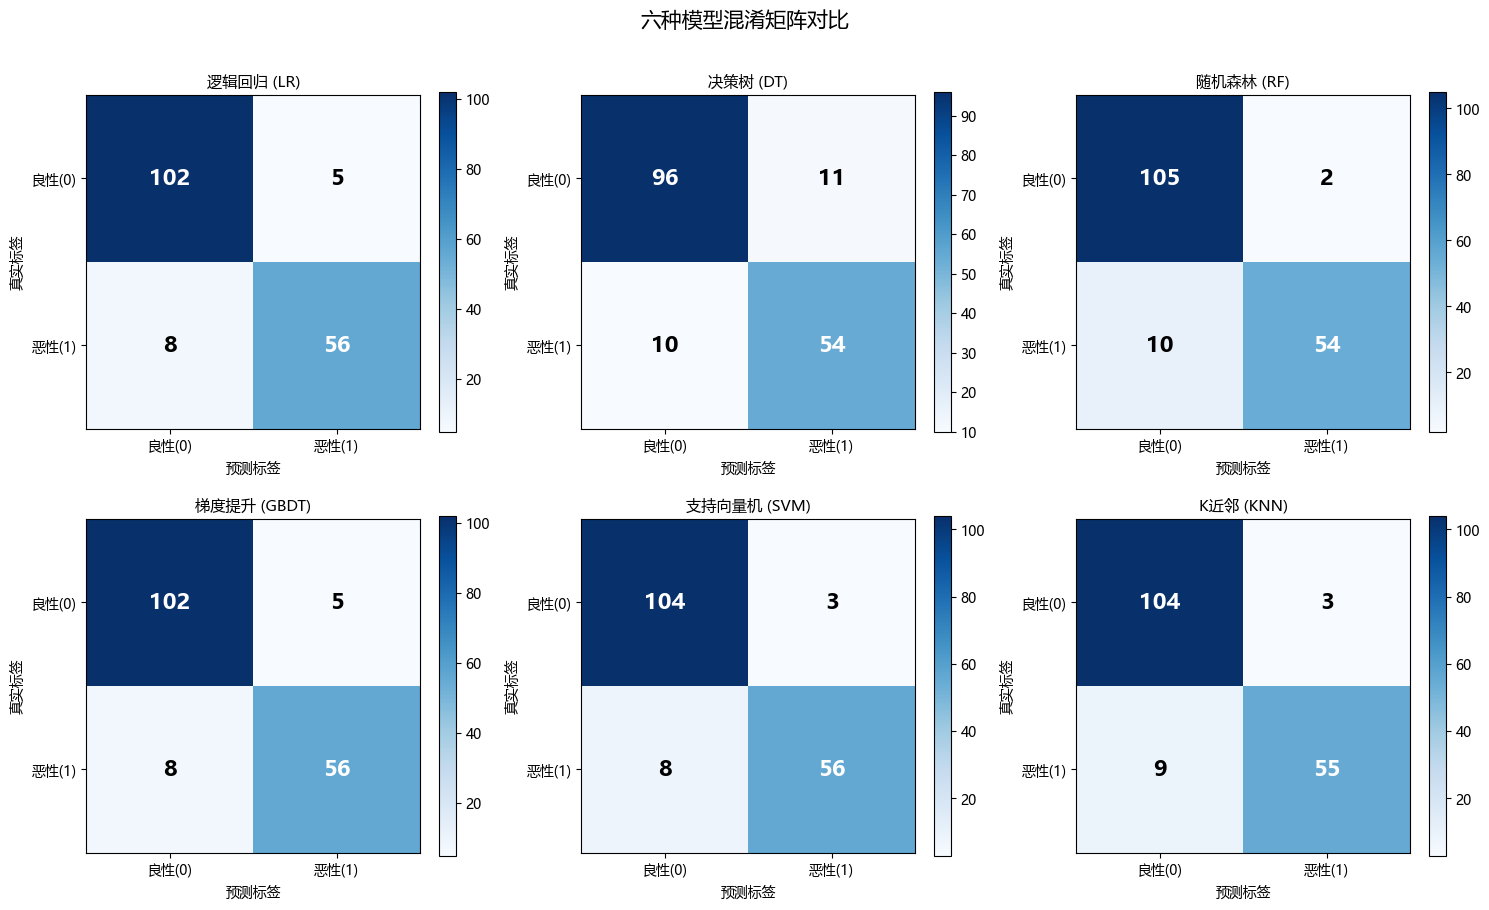

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, (model, y_pred, y_prob)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    im = axes[idx].imshow(cm, cmap='Blues')
    axes[idx].set_title(name, fontsize=11)
    axes[idx].set_xlabel('预测标签')
    axes[idx].set_ylabel('真实标签')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['良性(0)', '恶性(1)'])
    axes[idx].set_yticklabels(['良性(0)', '恶性(1)'])
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, str(cm[i, j]),
                           ha='center', va='center',
                           fontsize=16, fontweight='bold',
                           color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.suptitle('六种模型混淆矩阵对比', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 ROC 曲线对比

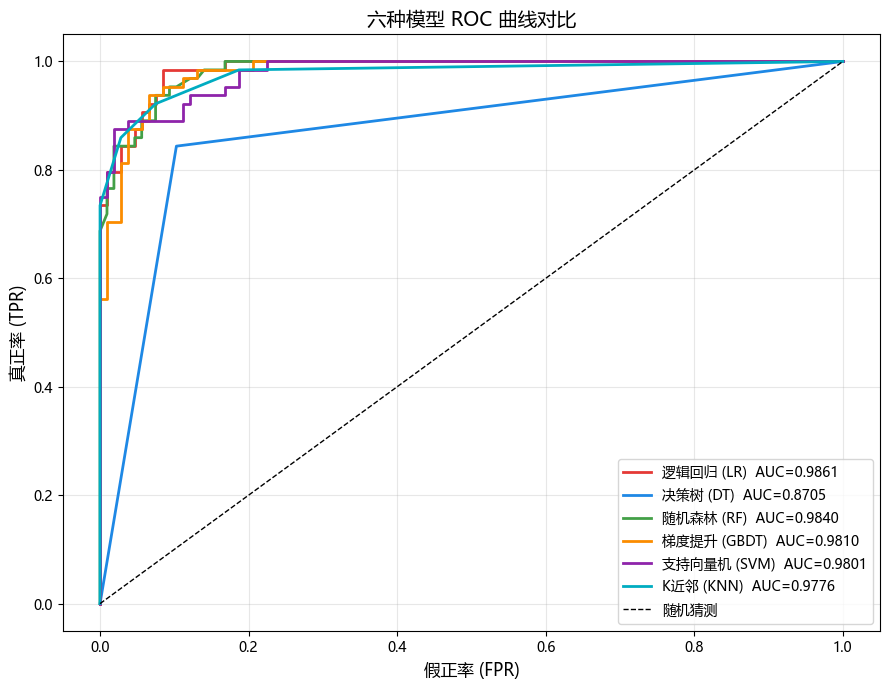

In [13]:
plt.figure(figsize=(9, 7))
colors_roc = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA', '#00ACC1']

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}  AUC={auc_val:.4f}')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')
plt.xlabel('假正率 (FPR)', fontsize=12)
plt.ylabel('真正率 (TPR)', fontsize=12)
plt.title('六种模型 ROC 曲线对比', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 准确率与 AUC 对比柱状图

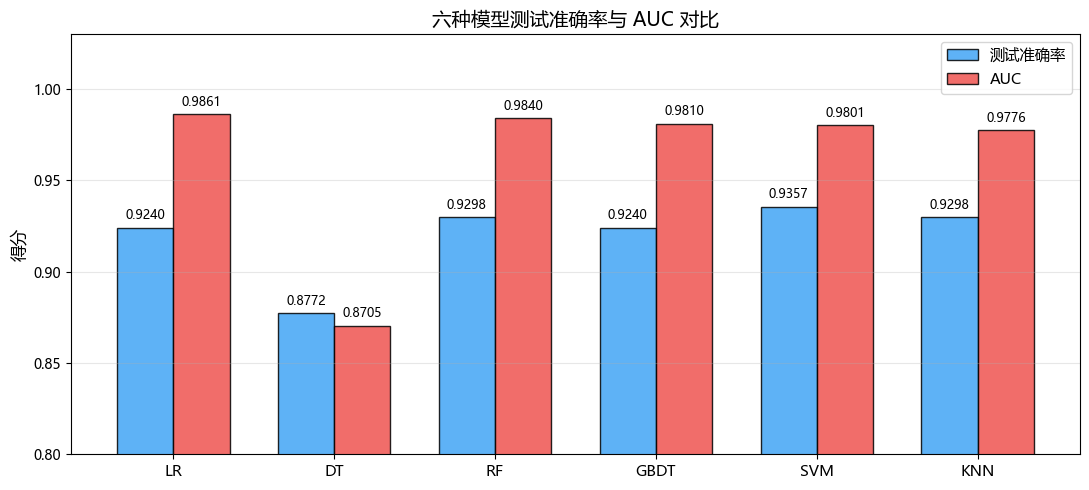

In [14]:
model_names_short = [n.split('(')[1].rstrip(')') for n in results_df.index]
acc_vals = results_df['测试准确率'].values
auc_vals = results_df['AUC'].values

x = np.arange(len(model_names_short))
width = 0.35

plt.figure(figsize=(11, 5))
bars1 = plt.bar(x - width / 2, acc_vals, width, label='测试准确率',
                color='#42A5F5', edgecolor='black', alpha=0.85)
bars2 = plt.bar(x + width / 2, auc_vals, width, label='AUC',
                color='#EF5350', edgecolor='black', alpha=0.85)

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.xticks(x, model_names_short, fontsize=11)
plt.ylim(0.8, 1.03)
plt.ylabel('得分', fontsize=12)
plt.title('六种模型测试准确率与 AUC 对比', fontsize=14)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 五折交叉验证准确率对比

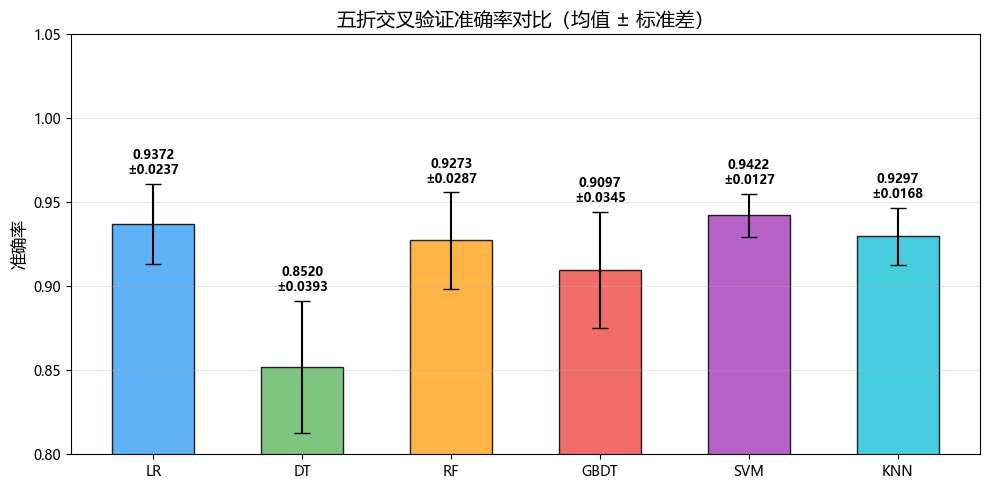

In [15]:
cv_means = results_df['5折CV均值'].values
cv_stds = results_df['5折CV标准差'].values

plt.figure(figsize=(10, 5))
bar_colors = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350', '#AB47BC', '#26C6DA']
bars = plt.bar(model_names_short, cv_means, yerr=cv_stds, capsize=6,
               color=bar_colors, edgecolor='black', alpha=0.85, width=0.55)
for bar, mean, std in zip(bars, cv_means, cv_stds):
    plt.text(bar.get_x() + bar.get_width() / 2,
             mean + std + 0.004,
             f'{mean:.4f}\n±{std:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.ylim(0.8, 1.05)
plt.ylabel('准确率', fontsize=12)
plt.title('五折交叉验证准确率对比（均值 ± 标准差）', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 F1 / 精确率 / 召回率雷达图

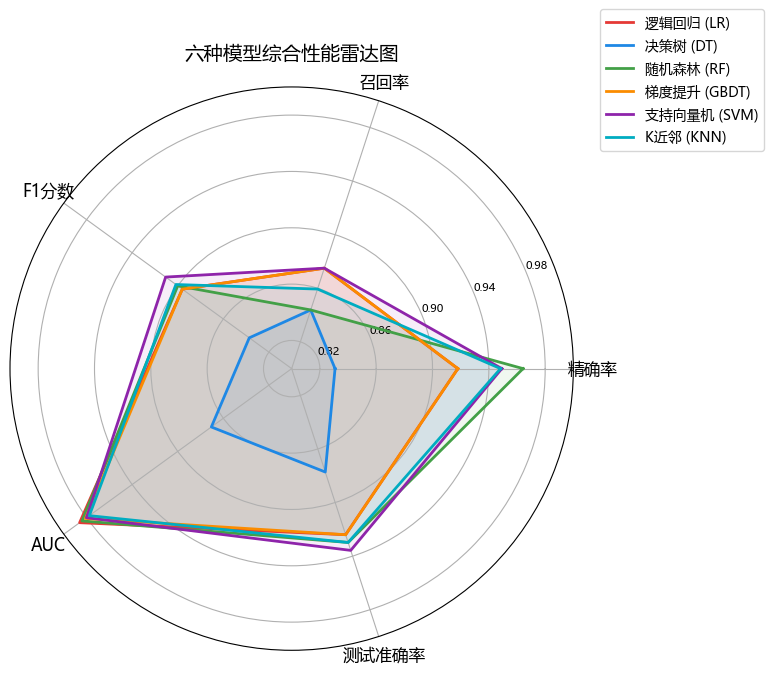

In [16]:
metrics_cols = ['精确率', '召回率', 'F1分数', 'AUC', '测试准确率']
labels = metrics_cols
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA', '#00ACC1']

for (idx, row), color in zip(results_df.iterrows(), radar_colors):
    values = row[metrics_cols].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=idx)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0.8, 1.0)
ax.set_yticks([0.82, 0.86, 0.90, 0.94, 0.98])
ax.set_yticklabels(['0.82', '0.86', '0.90', '0.94', '0.98'], fontsize=8)
ax.set_title('六种模型综合性能雷达图', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

### 5.8 随机森林特征重要性

In [17]:
rf_model = trained_models['随机森林 (RF)'][0]
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    '特征': X.columns,
    '重要性': importances
}).sort_values('重要性', ascending=False).reset_index(drop=True)

feat_imp_df

,特征,重要性
0,radius_mean,0.333897
1,radius_se,0.139009
2,compactness_mean,0.125095
3,texture_mean,0.091763
4,smoothness_mean,0.069523
5,symmetry_mean,0.047042
6,fractal_dimension_mean,0.041178
7,compactness_se,0.037186
8,symmetry_se,0.035739
9,smoothness_se,0.030266


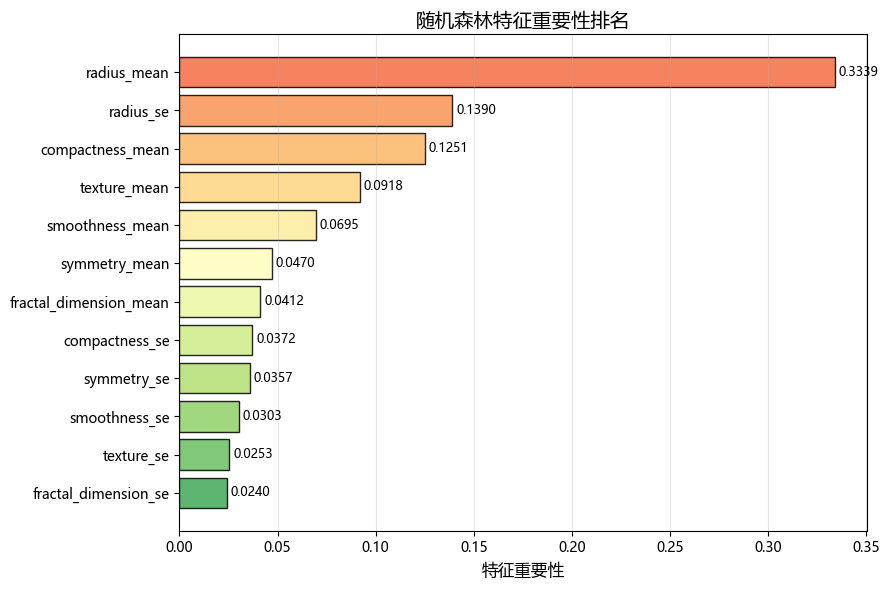

In [18]:
palette = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(feat_imp_df)))[::-1]

plt.figure(figsize=(9, 6))
bars = plt.barh(feat_imp_df['特征'][::-1], feat_imp_df['重要性'][::-1],
                color=palette, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, feat_imp_df['重要性'][::-1]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('特征重要性', fontsize=12)
plt.title('随机森林特征重要性排名', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 最终结果汇总

In [19]:
best_model = results_df['AUC'].idxmax()
print(f'综合 AUC 最优模型：{best_model}')
print()
results_df.sort_values('AUC', ascending=False)

综合 AUC 最优模型：逻辑回归 (LR)



,测试准确率,精确率,召回率,F1分数,AUC,5折CV均值,5折CV标准差
模型,,,,,,,
逻辑回归 (LR),0.9240,0.9180,0.8750,0.8960,0.9861,0.9372,0.0237
随机森林 (RF),0.9298,0.9643,0.8438,0.9000,0.9840,0.9273,0.0287
梯度提升 (GBDT),0.9240,0.9180,0.8750,0.8960,0.9810,0.9097,0.0345
支持向量机 (SVM),0.9357,0.9492,0.8750,0.9106,0.9801,0.9422,0.0127
K近邻 (KNN),0.9298,0.9483,0.8594,0.9016,0.9776,0.9297,0.0168
决策树 (DT),0.8772,0.8308,0.8438,0.8372,0.8705,0.8520,0.0393


In [20]:
best_name = results_df['AUC'].idxmax()
best_model_obj, best_pred, _ = trained_models[best_name]
print(f'最优模型 [{best_name}] 详细分类报告：')
print(classification_report(y_test, best_pred,
                             target_names=['良性 (B)', '恶性 (M)']))

最优模型 [逻辑回归 (LR)] 详细分类报告：
              precision    recall  f1-score   support

      良性 (B)       0.93      0.95      0.94       107
      恶性 (M)       0.92      0.88      0.90        64

    accuracy                           0.92       171
   macro avg       0.92      0.91      0.92       171
weighted avg       0.92      0.92      0.92       171

